In [ ]:
# All Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score,
                              classification_report, confusion_matrix)

print("✅ All Libraries Imported!")

✅ All Libraries Imported!


In [4]:
import pandas as pd
df=pd.read_csv("/content/diabetes.csv")

print("✅ Data Loaded!")
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print(f"\nColumns : {df.columns.tolist()}")
df.head()

✅ Data Loaded!
Rows    : 768
Columns : 9

Columns : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
print("📋 Data Types:")
print(df.dtypes)

print("\n❓ Missing Values:")
print(df.isnull().sum())

print("\n🎯 Target Distribution:")
print(df['Outcome'].value_counts())
print(f"\nDiabetes  : {df['Outcome'].sum()} ({df['Outcome'].mean()*100:.1f}%)")
print(f"No Diabetes: {(df['Outcome']==0).sum()} ({(1-df['Outcome'].mean())*100:.1f}%)")

📋 Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

❓ Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

🎯 Target Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Diabetes  : 268 (34.9%)
No Diabetes: 500 (65.1%)


In [6]:
#Statistical Summary

print("📈 Statistical Summary:")
df.describe().round(2)

📈 Statistical Summary:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [7]:
#Zero Values Check
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

print("⚠️ Zero Values (actually missing data):")
for col in zero_cols:
    count = (df[col] == 0).sum()
    pct   = count / len(df) * 100
    print(f"  {col:20s}: {count} zeros ({pct:.1f}%)")

⚠️ Zero Values (actually missing data):
  Glucose             : 5 zeros (0.7%)
  BloodPressure       : 35 zeros (4.6%)
  SkinThickness       : 227 zeros (29.6%)
  Insulin             : 374 zeros (48.7%)
  BMI                 : 11 zeros (1.4%)


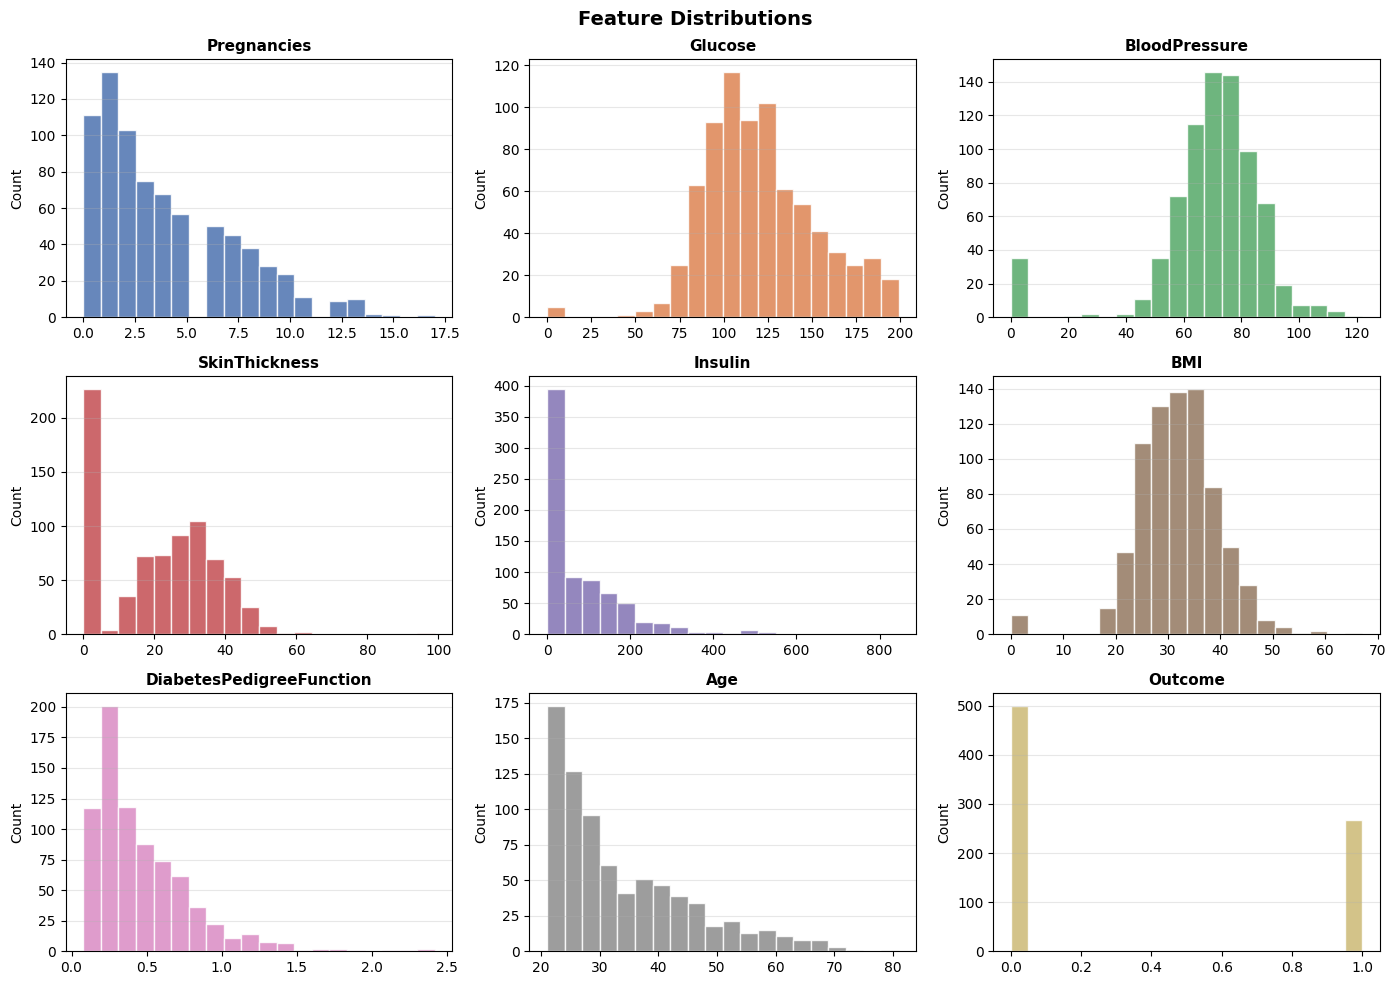

In [9]:
#Distribution Plot

import matplotlib.pyplot as plt
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes      = axes.flatten()
colors    = ['#4C72B0','#DD8452','#55A868','#C44E52',
             '#8172B3','#937860','#DA8BC3','#8C8C8C','#CCB974']

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=20,
                 color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Count')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

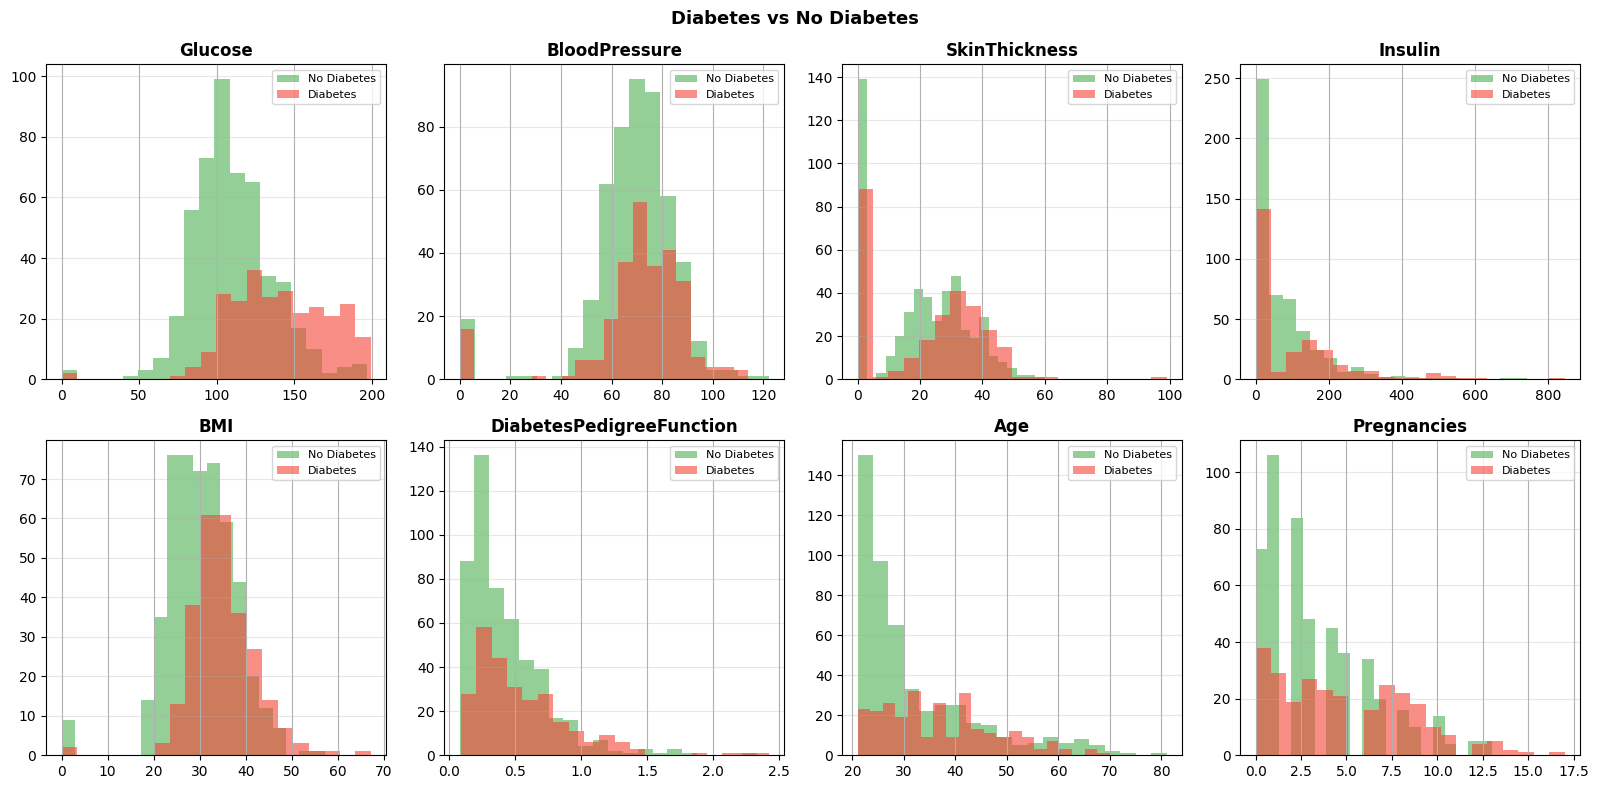

In [10]:
#Diabetes vs No Diabetes

features = ['Glucose','BloodPressure','SkinThickness','Insulin',
            'BMI','DiabetesPedigreeFunction','Age','Pregnancies']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes      = axes.flatten()

for i, col in enumerate(features):
    df[df['Outcome']==0][col].hist(
        ax=axes[i], bins=20, alpha=0.6,
        color='#4CAF50', label='No Diabetes')
    df[df['Outcome']==1][col].hist(
        ax=axes[i], bins=20, alpha=0.6,
        color='#F44336', label='Diabetes')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Diabetes vs No Diabetes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

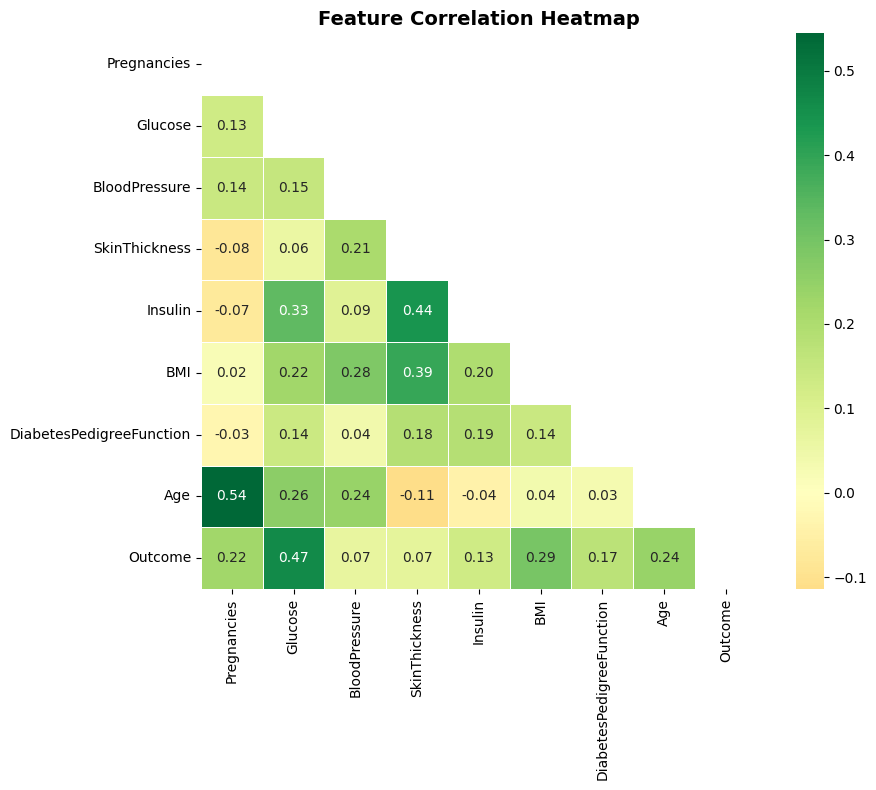


🔑 Correlation with Diabetes (Outcome):
  Glucose                  : +0.467  █████████
  BMI                      : +0.293  █████
  Age                      : +0.238  ████
  Pregnancies              : +0.222  ████
  DiabetesPedigreeFunction : +0.174  ███
  Insulin                  : +0.131  ██
  SkinThickness            : +0.075  █
  BloodPressure            : +0.065  █


In [12]:
#Correlation Heatmap
import numpy as np
import seaborn as sns

plt.figure(figsize=(10, 8))
corr   = df.corr(numeric_only=True)
mask   = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            mask=mask, square=True, linewidths=0.5)

plt.title('Feature Correlation Heatmap',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔑 Correlation with Diabetes (Outcome):")
corr_outcome = corr['Outcome'].drop('Outcome').sort_values(ascending=False)
for col, val in corr_outcome.items():
    bar = "█" * int(abs(val) * 20)
    print(f"  {col:25s}: {val:+.3f}  {bar}")

In [13]:
#Data Cleaning

df_clean = df.copy()

for col in zero_cols:
    median_val          = df_clean[col].median()
    df_clean[col]       = df_clean[col].replace(0, median_val)

print("✅ Zero Values Fixed!")
print("\nAfter cleaning — Zero count:")
for col in zero_cols:
    print(f"  {col:20s}: {(df_clean[col]==0).sum()} zeros ✅")

✅ Zero Values Fixed!

After cleaning — Zero count:
  Glucose             : 0 zeros ✅
  BloodPressure       : 0 zeros ✅
  SkinThickness       : 0 zeros ✅
  Insulin             : 0 zeros ✅
  BMI                 : 0 zeros ✅


In [15]:
#Train Test Split
from sklearn.model_selection import train_test_split

X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42, stratify=y
)

print("✅ Train Test Split Done!")
print(f"Train : {X_train.shape[0]} samples (80%)")
print(f"Test  : {X_test.shape[0]} samples (20%)")
print(f"\nTrain Diabetes % : {y_train.mean()*100:.1f}%")
print(f"Test  Diabetes % : {y_test.mean()*100:.1f}%")

✅ Train Test Split Done!
Train : 614 samples (80%)
Test  : 154 samples (20%)

Train Diabetes % : 34.9%
Test  Diabetes % : 35.1%


In [17]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Scaling Done!")
print(f"Before → Glucose mean : {X_train['Glucose'].mean():.2f}")
print(f"After  → Glucose mean : {X_train_scaled[:,1].mean():.4f} (≈ 0)")
print(f"Before → Glucose std  : {X_train['Glucose'].std():.2f}")
print(f"After  → Glucose std  : {X_train_scaled[:,1].std():.4f} (≈ 1)")

✅ Scaling Done!
Before → Glucose mean : 121.67
After  → Glucose mean : -0.0000 (≈ 0)
Before → Glucose std  : 30.00
After  → Glucose std  : 1.0000 (≈ 1)


In [20]:
# 3 Models Train
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

models = {
    'Logistic Regression' : LogisticRegression(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:,1]
    acc    = accuracy_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'accuracy': acc, 'auc': auc}
    print(f"✅ {name:25s} Accuracy: {acc*100:.2f}%  AUC: {auc:.4f}")

print("\n🏆 Best Model Selected!")

✅ Logistic Regression       Accuracy: 70.78%  AUC: 0.8152
✅ Random Forest             Accuracy: 75.97%  AUC: 0.8200
✅ Gradient Boosting         Accuracy: 75.97%  AUC: 0.8267

🏆 Best Model Selected!


In [22]:
#Fine Tune
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 4, 5],
    'learning_rate' : [0.05, 0.1],
    'subsample'     : [0.8, 1.0]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid, cv=5,
    scoring='roc_auc', n_jobs=-1
)

print("⏳ Fine-tuning... 2-3 mins wait பண்ணு...")
grid_search.fit(X_train_scaled, y_train)

print("✅ Fine-tuning Done!")
print("Best Params:", grid_search.best_params_)
print("Best Score :", round(grid_search.best_score_, 4))

⏳ Fine-tuning... 2-3 mins wait பண்ணு...
✅ Fine-tuning Done!
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best Score : 0.8304


In [24]:
#Final Evaluation
from sklearn.metrics import classification_report

tuned_model = grid_search.best_estimator_
y_pred      = tuned_model.predict(X_test_scaled)
y_prob      = tuned_model.predict_proba(X_test_scaled)[:,1]
acc         = accuracy_score(y_test, y_pred)
auc         = roc_auc_score(y_test, y_prob)

print("="*45)
print("   📊 FINAL MODEL RESULTS")
print("="*45)
print(f"\n✅ Accuracy : {acc*100:.2f}%")
print(f"✅ ROC-AUC  : {auc:.4f}")
print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['No Diabetes','Diabetes']))

   📊 FINAL MODEL RESULTS

✅ Accuracy : 74.68%
✅ ROC-AUC  : 0.8270

📋 Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.78      0.85      0.81       100
    Diabetes       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154



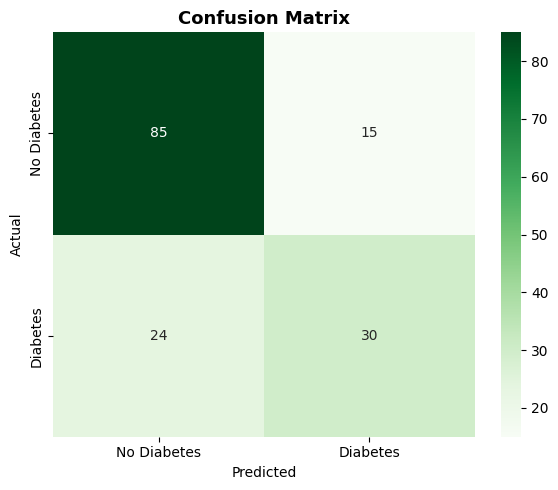


✅ Correctly → No Diabetes : 85
✅ Correctly → Diabetes    : 30
❌ Missed Diabetes         : 24
❌ Wrong Diabetes          : 15


In [26]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Diabetes','Diabetes'],
            yticklabels=['No Diabetes','Diabetes'])
plt.title('Confusion Matrix', fontweight='bold', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\n✅ Correctly → No Diabetes : {tn}")
print(f"✅ Correctly → Diabetes    : {tp}")
print(f"❌ Missed Diabetes         : {fn}")
print(f"❌ Wrong Diabetes          : {fp}")

In [27]:
#SHAP Install

!pip install shap -q
import shap

explainer   = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_test_scaled)

print("✅ SHAP Ready!")
print(f"   Version : {shap.__version__}")
print(f"   Shape   : {shap_values.shape}")

✅ SHAP Ready!
   Version : 0.51.0
   Shape   : (154, 8)


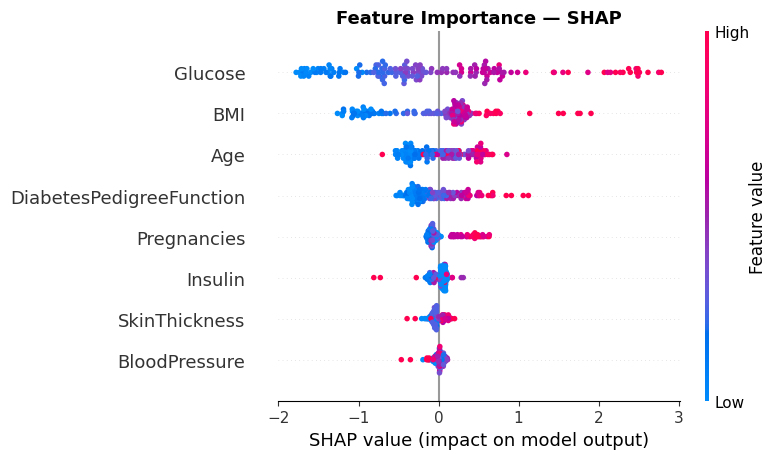


🔑 SHAP — Top Features:
  Glucose                  : 0.9440  ████████████████████████████
  BMI                      : 0.5039  ███████████████
  Age                      : 0.3122  █████████
  DiabetesPedigreeFunction : 0.2746  ████████
  Pregnancies              : 0.1592  ████
  Insulin                  : 0.0829  ██
  SkinThickness            : 0.0671  ██
  BloodPressure            : 0.0438  █


In [28]:
#SHAP Summary Plot

plt.figure()
shap.summary_plot(
    shap_values, X_test,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title("Feature Importance — SHAP",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔑 SHAP — Top Features:")
mean_shap = np.abs(shap_values).mean(axis=0)
feat_imp  = pd.Series(mean_shap,
                      index=X.columns).sort_values(ascending=False)
for feat, val in feat_imp.items():
    bar = "█" * int(val * 30)
    print(f"  {feat:25s}: {val:.4f}  {bar}")

  🔍 PATIENT RISK EXPLANATION

Actual    : 🟢 No Diabetes
Predicted : 🔴 Diabetes
Risk      : 78.6%


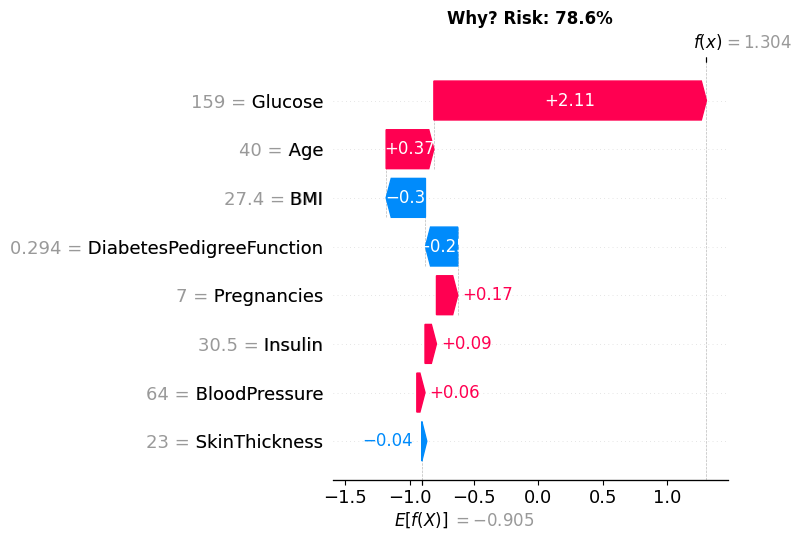

In [29]:
#SHAP Single Patient

idx     = 0
patient = X_test.iloc[[idx]]
actual  = y_test.iloc[idx]
pred    = tuned_model.predict(X_test_scaled[idx:idx+1])[0]
prob    = tuned_model.predict_proba(
              X_test_scaled[idx:idx+1])[0][1]

print("="*45)
print("  🔍 PATIENT RISK EXPLANATION")
print("="*45)
print(f"\nActual    : {'🔴 Diabetes' if actual==1 else '🟢 No Diabetes'}")
print(f"Predicted : {'🔴 Diabetes' if pred==1 else '🟢 No Diabetes'}")
print(f"Risk      : {prob*100:.1f}%")

shap_patient = explainer.shap_values(
    X_test_scaled[idx:idx+1]
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values        = shap_patient[0],
        base_values   = explainer.expected_value,
        data          = patient.values[0],
        feature_names = X.columns.tolist()
    ),
    show=False
)
plt.title(f"Why? Risk: {prob*100:.1f}%", fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
#Model Save

import joblib

joblib.dump(tuned_model, 'best_model.pkl')
joblib.dump(scaler,      'scaler.pkl')

print("✅ Model saved  : best_model.pkl")
print("✅ Scaler saved : scaler.pkl")
print("\n🎯 All Steps Complete!")
print("="*45)

✅ Model saved  : best_model.pkl
✅ Scaler saved : scaler.pkl

🎯 All Steps Complete!


In [32]:
# Streamlit & ngrok install
!pip install streamlit pyngrok -q

print("✅ Installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 16.6 MB/s eta 0:00:00
✅ Installed!


In [33]:
app_code = """
import streamlit as st
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

model  = joblib.load('best_model.pkl')
scaler = joblib.load('scaler.pkl')

st.set_page_config(
    page_title="Diabetes Prediction",
    page_icon="🏥"
)

st.title("🏥 Diabetes Risk Prediction")
st.markdown("*Powered by Gradient Boosting + SHAP*")
st.divider()

st.sidebar.header("Patient Details")
glucose  = st.sidebar.slider("Glucose Level",    0, 200, 120)
bmi      = st.sidebar.slider("BMI",              10.0, 60.0, 25.0)
age      = st.sidebar.slider("Age",              18, 90, 30)
bp       = st.sidebar.slider("Blood Pressure",   0, 130, 70)
insulin  = st.sidebar.slider("Insulin",          0, 900, 80)
skin     = st.sidebar.slider("Skin Thickness",   0, 100, 20)
dpf      = st.sidebar.slider("Diabetes Pedigree",0.0, 2.5, 0.5)
preg     = st.sidebar.slider("Pregnancies",      0, 17, 1)

input_data   = np.array([[preg, glucose, bp,
                           skin, insulin, bmi, dpf, age]])
input_scaled = scaler.transform(input_data)
prediction   = model.predict(input_scaled)[0]
probability  = model.predict_proba(input_scaled)[0][1]

st.subheader("Prediction Result")
col1, col2 = st.columns(2)

with col1:
    if prediction == 1:
        st.error(f"⚠️ High Diabetes Risk!")
    else:
        st.success(f"✅ Low Diabetes Risk!")
    st.metric("Risk Probability", f"{probability*100:.1f}%")
    st.progress(float(probability))

with col2:
    import shap
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(input_scaled)
    feature_names = ['Pregnancies','Glucose','BloodPressure',
                     'SkinThickness','Insulin','BMI',
                     'DiabetesPedigree','Age']
    fig, ax = plt.subplots(figsize=(8,4))
    shap.waterfall_plot(
        shap.Explanation(
            values        = shap_values[0],
            base_values   = explainer.expected_value,
            data          = input_data[0],
            feature_names = feature_names
        ),
        show=False
    )
    st.pyplot(fig)
    st.caption("Why this prediction? — SHAP")
"""

# app.py file create
with open('app.py', 'w') as f:
    f.write(app_code)

print("✅ app.py created!")

✅ app.py created!


In [37]:
from pyngrok import ngrok
import subprocess
import threading
import time

ngrok.set_auth_token("3BT9mw9O6KwkTm29NuNsfMfVikB_37KFbyQVw2DdQPDSKEyDw")

def run_streamlit():
    subprocess.run([
        'streamlit', 'run', 'app.py',
        '--server.port', '8501',
        '--server.headless', 'true'
    ])

thread = threading.Thread(target=run_streamlit)
thread.daemon = True
thread.start()

time.sleep(5)

public_url = ngrok.connect(8501)
print("🌐 LIVE APP LINK:")
print(f"👉 {public_url}")

🌐 LIVE APP LINK:
👉 NgrokTunnel: "https://sherril-unrestrained-askew.ngrok-free.dev" -> "http://localhost:8501"


In [38]:
from google.colab import files

files.download('app.py')
files.download('best_model.pkl')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>